# Support Vector Machine (SVM) - Coding Assignment (Total: 75 Points)

## **Objective:**
In this assignment, you will work with the **Predicting a Pulsar Star dataset** and use **Support Vector Machines (SVM)** to classify pulsar stars. You will:
- Perform **Exploratory Data Analysis (EDA)**.
- Preprocess the dataset (**handling missing values, outliers, and scaling**).
- Implement **Soft-Margin SVM** and **Kernel SVM**.
- Tune **hyperparameters** (C and kernel type) to optimize model performance.
- Compare different models and interpret results.

---

## **1. Load Libraries and Dataset**



Criteria	Points
1. Preprocessing
- Task 2: Preprocess the dataset	5
- Handle outliers using boxplots	5
- Split data and scale features	3
2. SVM Training & Evaluation
- Train SVM Classifier	5
- Tune hyperparameters: kernel and C value	10
- Experiment with different C values (C = 10, C = 1000), compare accuracy	5
- Compare train and test accuracy to detect overfitting	5
- Print training set accuracy and compare with test accuracy	5
- Tune hyperparameters: kernel and C value (repeated step, assumed to support additional trials)	5
- Train SVM with RBF and sigmoid kernels, compare results	10
3. Evaluation Metrics
- Compute and visualize the Confusion Matrix	10
4. Markdown Questions
- Answer 7 markdown questions (1 point each)	7

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Load dataset
data_path = "pulsar_stars.csv"
df = pd.read_csv(data_path)

# Display first 5 rows
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


## **2. Exploratory Data Analysis (EDA)**
### Task 1: Check dataset dimensions, column names, and missing values.

In [3]:
# Dataset shape
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Dataset shape: (17898, 9)

Column names:
[' Mean of the integrated profile', ' Standard deviation of the integrated profile', ' Excess kurtosis of the integrated profile', ' Skewness of the integrated profile', ' Mean of the DM-SNR curve', ' Standard deviation of the DM-SNR curve', ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve', 'target_class']

Missing values per column:
 Mean of the integrated profile                  0
 Standard deviation of the integrated profile    0
 Excess kurtosis of the integrated profile       0
 Skewness of the integrated profile              0
 Mean of the DM-SNR curve                        0
 Standard deviation of the DM-SNR curve          0
 Excess kurtosis of the DM-SNR curve             0
 Skewness of the DM-SNR curve                    0
target_class                                     0
dtype: int64

Total missing values: 0


"""
### **Task 2: Preprocess the dataset** (5 points)
1. Remove leading spaces in column names.
2. Rename columns to short and meaningful names.
3. Check for class imbalance in the `target_class` column.
"""

Updated column names:
['ip_mean', 'ip_std', 'ip_kurtosis', 'ip_skewness', 'dm_mean', 'dm_std', 'dm_kurtosis', 'dm_skewness', 'target_class']

Class counts:
target_class
0    16259
1     1639
Name: count, dtype: int64

Class percentages:
target_class
0    90.842552
1     9.157448
Name: proportion, dtype: float64


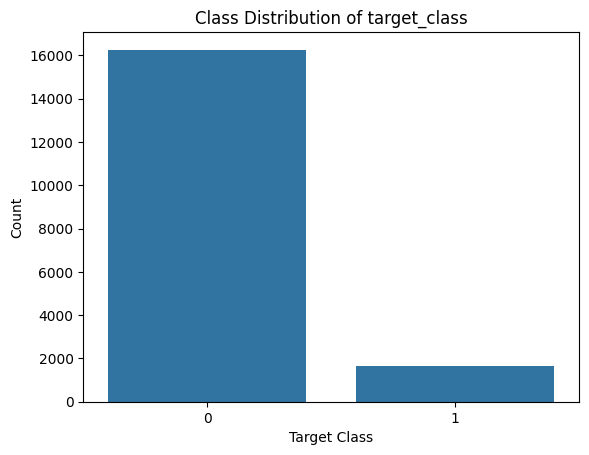

In [4]:
# Remove leading spaces
df.columns = df.columns.str.strip()

df.columns = [
    "ip_mean",
    "ip_std",
    "ip_kurtosis",
    "ip_skewness",
    "dm_mean",
    "dm_std",
    "dm_kurtosis",
    "dm_skewness",
    "target_class"
]

print("Updated column names:")
print(df.columns.tolist())
\
class_counts = df["target_class"].value_counts()
class_percent = df["target_class"].value_counts(normalize=True) * 100

print("\nClass counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

sns.countplot(x="target_class", data=df)
plt.title("Class Distribution of target_class")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

## **3. Handle Outliers Using Boxplots** (5 points)
### Task 3: Visualize and handle outliers in continuous features.
"""

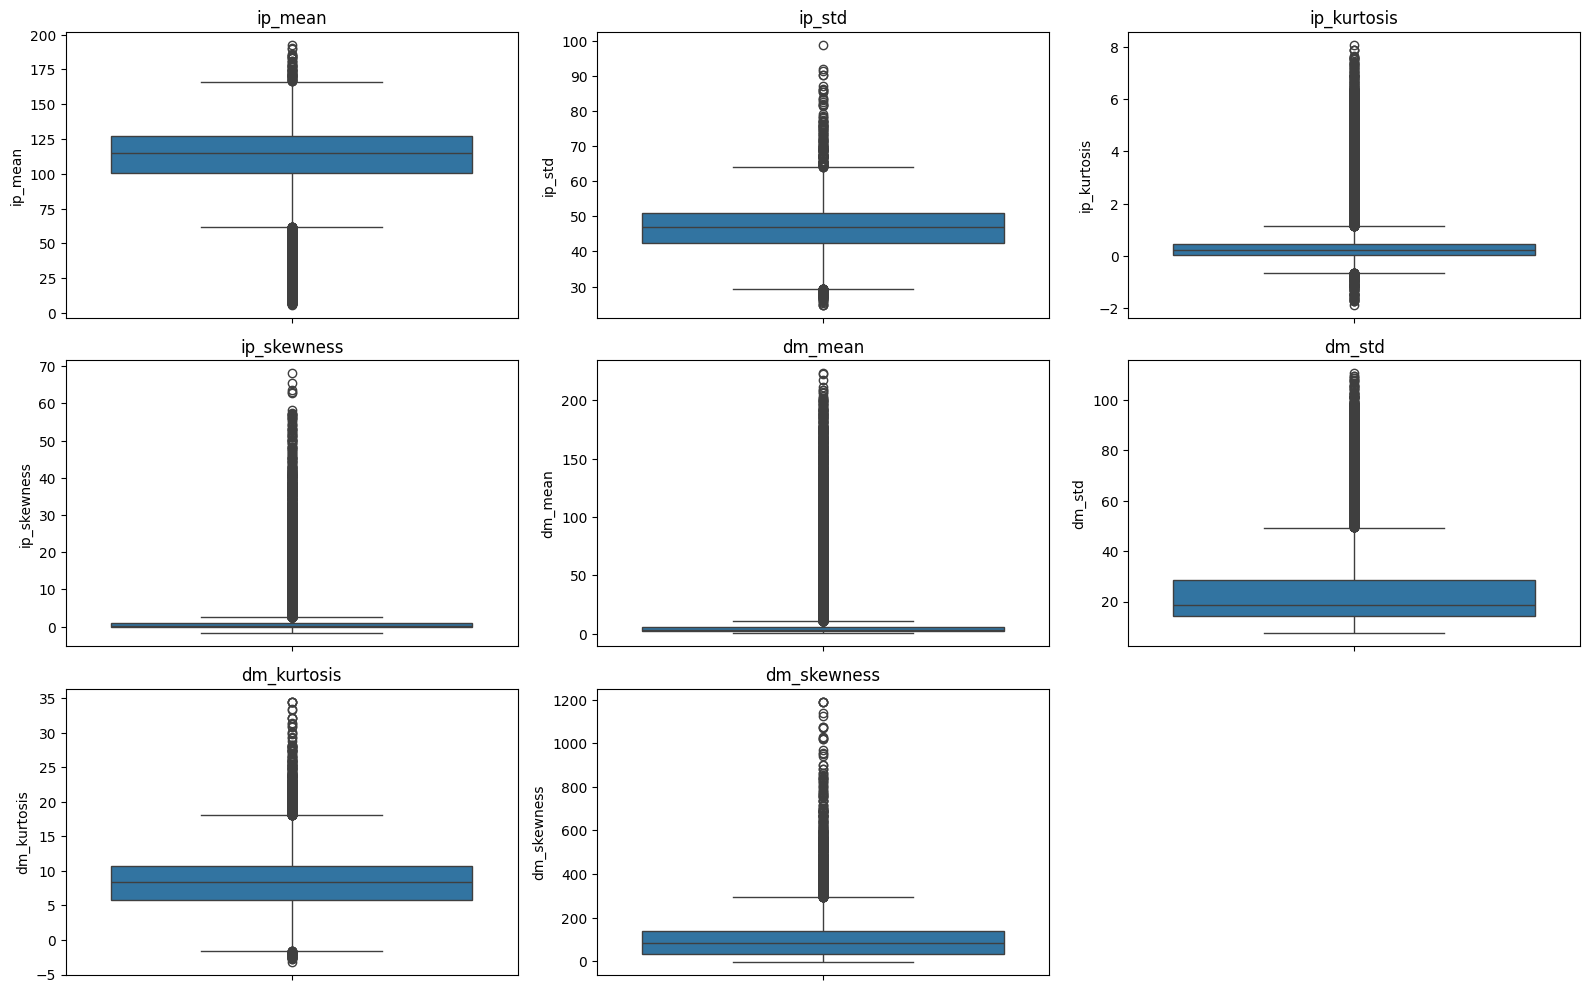

In [5]:
feature_cols = [col for col in df.columns if col != "target_class"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

"""
## **4. Split Data and Scale Features** (3 points)
### Task 4: Split the dataset into training and test sets (80-20 split) and apply **Standard Scaling**.
"""

In [6]:
# Define feature matrix X and target variable y
X = df.drop(['target_class'], axis=1)
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

X_train shape: (14318, 8)
X_test shape: (3580, 8)
y_train shape: (14318,)
y_test shape: (3580,)

Feature scaling completed.
Scaled training data shape: (14318, 8)
Scaled test data shape: (3580, 8)


"""
## **5. Train Support Vector Machine (SVM) Classifier** (5 points)
### Task 5: Train an SVM model with **default hyperparameters (C=1.0, RBF Kernel)** and evaluate performance.
"""

In [7]:
# Task 5: Train SVM with default hyperparameters
svc_default = SVC(C=1.0, kernel='rbf', random_state=42)
svc_default.fit(X_train_scaled, y_train)

y_pred_default = svc_default.predict(X_test_scaled)

default_accuracy = accuracy_score(y_test, y_pred_default)
print("Default SVM Test Accuracy:", default_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))

cm_default = confusion_matrix(y_test, y_pred_default)
print("\nConfusion Matrix:")
print(cm_default)

Default SVM Test Accuracy: 0.9807262569832402

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.95      0.84      0.89       328

    accuracy                           0.98      3580
   macro avg       0.97      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580


Confusion Matrix:
[[3237   15]
 [  54  274]]


"""
## **6. Tune Hyperparameters: Kernel and C Value** (10 points)
### Task 6: Train SVM with **RBF kernel and C=100** and compare performance.
"""

In [8]:
svc_c100 = SVC(C=100, kernel='rbf', random_state=42)
svc_c100.fit(X_train_scaled, y_train)

y_pred_c100 = svc_c100.predict(X_test_scaled)

c100_accuracy = accuracy_score(y_test, y_pred_c100)
print("SVM (C=100) Test Accuracy:", c100_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_c100))

SVM (C=100) Test Accuracy: 0.9812849162011174

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.94      0.85      0.89       328

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



### Task 7: Experiment with different values of C (C=10, C=1000) and compare  the accuracy. (5 points)
Try modifying the C value and analyze its impact on overfitting.


In [9]:
c_values = [10, 100, 1000]
results = []

for c in c_values:
    model = SVC(C=c, kernel='rbf', random_state=42)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    results.append([c, train_acc, test_acc])

results_df = pd.DataFrame(results, columns=["C", "Train Accuracy", "Test Accuracy"])
print(results_df)

      C  Train Accuracy  Test Accuracy
0    10        0.981841       0.981006
1   100        0.983587       0.981285
2  1000        0.985752       0.979050


## **8. Compare Train and Test Accuracy to Detect Overfitting** (5 points)

---



In [12]:
results = []

for c in [1, 10, 100, 1000]:
    model = SVC(C=c, kernel='rbf', random_state=42)
    model.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    results.append((c, train_acc, test_acc))

## **9. Print training set accuracy and compare with test accuracy.** (5 points)

---

In [13]:
for c, train_acc, test_acc in results:
    print(f"C={c}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    print(f"Difference:        {train_acc - test_acc:.4f}\n")

C=1
Training Accuracy: 0.9795
Test Accuracy:     0.9807
Difference:        -0.0012

C=10
Training Accuracy: 0.9818
Test Accuracy:     0.9810
Difference:        0.0008

C=100
Training Accuracy: 0.9836
Test Accuracy:     0.9813
Difference:        0.0023

C=1000
Training Accuracy: 0.9858
Test Accuracy:     0.9791
Difference:        0.0067



"""
## **10. Tune Hyperparameters: Kernel and C Value** (5 points)
###

In [14]:
models = {
    "RBF_C1": SVC(C=1, kernel='rbf', random_state=42),
    "RBF_C10": SVC(C=10, kernel='rbf', random_state=42),
    "RBF_C100": SVC(C=100, kernel='rbf', random_state=42),
    "RBF_C1000": SVC(C=1000, kernel='rbf', random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")

RBF_C1: 0.9807
RBF_C10: 0.9810
RBF_C100: 0.9813
RBF_C1000: 0.9791


"""
## **11. Train SVM with Different Kernels**
###  Train SVM with a **RBF and sigmoid kernel** and compare results. (10 points)
"""

In [15]:
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_sigmoid = SVC(kernel='sigmoid', C=1.0, random_state=42)

svm_rbf.fit(X_train_scaled, y_train)
svm_sigmoid.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_sigmoid = svm_sigmoid.predict(X_test_scaled)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Sigmoid Kernel Accuracy:", accuracy_score(y_test, y_pred_sigmoid))

RBF Kernel Accuracy: 0.9807262569832402
Sigmoid Kernel Accuracy: 0.8770949720670391


"""
## **12. Evaluate Model Performance Using Confusion Matrix**
### Compute and visualize the Confusion Matrix. (10 points)
"""

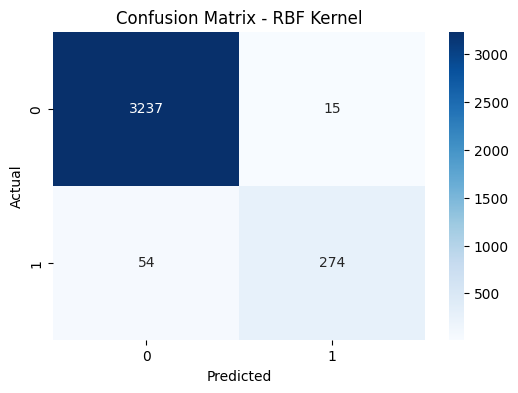

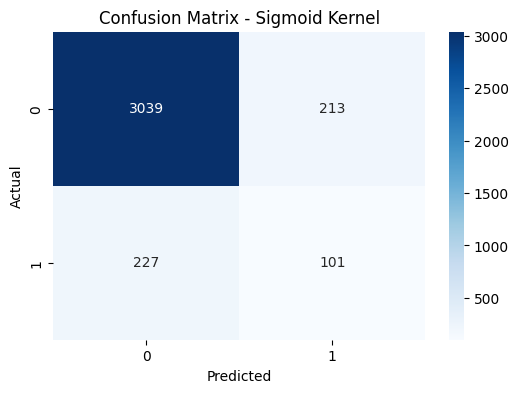

In [18]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
cm_sigmoid = confusion_matrix(y_test, y_pred_sigmoid)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(cm_sigmoid, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Sigmoid Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

"""
### **Final Task: Answer the following questions in markdown cells.** (1 point each)
1. What is the effect of increasing the C value on the SVM model?
2. Why does the linear kernel perform differently than the RBF kernel?
3. How does feature scaling impact SVM performance?
4. What happens if we don’t handle outliers before training an SVM model?
5. Explain the concept of soft-margin SVM and why it is useful in handling noisy data.
6. Why does the sigmoid kernel perform poorly compared to other kernels?
7. What does the confusion matrix reveal about the model’s predictions?

---

1. Increasing the C value means that the SVM model penalizes incorrect classifications more harshly. Higher C values mean that the model will fit the training data more closely together with a smaller margin. A lower C value means that there is a wider margin and more mistakes in classification will be permitted by the SVM model.

2. The linear kernel only creates a straight line decision boundary in the feature space because that is all that it is capable of doing. The RBF kernel is capable of creating non-linear decision boundaries which allows the SVM model to be much more flexible.

3. Feature scaling helps the SVM model performance by putting all features on a similar scale. This helps by improving model stability and makes the optimization converge properly.

4. Outliers can strongly affect the performance of the SVM model. Because the SVM's goal is to create a decision line separating the data, outliers can drastically change where the SVM chooses to place this line. This is especially true in cases with high C values. Not handling outliers beforehand can lead to misclassification of normal points and less stability overall.

5. Soft-margin SVM allows for points to lie inside the margin and even in some cases be misclassified. This is particularly useful when handling noisy data because noisy data overlaps and contains imperfections meaning if the SVM insisted on separating every point perfectly, there would be a large amount of overfitting. Soft-margin SVM is good for these cases.

6. The sigmoid kernel is more sensitive to parameter settings and often produces a decision boundary that is not as flexible or stable as other kernels. The sigmoid kernel requires the data to already be at the right scale or parameter range to perform well.

7. The final confusion matrix reveals that the RBF kernel did a better job with its predictions than the sigmoid kernel. The RBF kernel correctly classified 3237 non-pulsars and 274 pulsars. The sigmoid kernel correctly classified 3039 non-pulsars and 101 pulsars.